# **3. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is conducted to understand the characteristics of the cleaned dataset through descriptive statistics and visualizations. This stage aims to identify patterns, examine variable distributions, detect potential outliers, and explore relationships among variables prior to feature engineering and model development.

## **Library Imports**

The following libraries are imported to support data manipulation, statistical analysis, and visualization during the exploratory data analysis stage.

In [1]:
# Importing Libraries

import pandas as pd          # For data manipulation
import numpy as np            # For mathematical operation
import matplotlib.pyplot as plt    # For data visualization
import seaborn as sns              # For data visualization

## **Data Ingestion**

The cleaned Framingham dataset is loaded into the working environment to facilitate exploratory data analysis. The dataset is then inspected to verify its dimensions and preview its contents.


In [12]:
df = pd.read_csv("data/processed/framingham_cleaned.csv")

print('Cleaned Framingham Data Loaded Successfully: \n')

print("Dataset Shape:")
print(df.shape)

df.head()

Cleaned Framingham Data Loaded Successfully: 

Dataset Shape:
(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


The output confirms that the cleaned Framingham dataset consists of 4,240 observations and 16 variables, indicating that the dataset has been successfully loaded and is ready for exploratory data analysis.

The preview of the first five observations confirms that the dataset has been loaded correctly and provides an initial view of the variables that will be explored in subsequent analyses.

### **Descriptive Summary Statistics**

Descriptive summary statistics were generated to provide an overview of the distribution, central tendency, and dispersion of the variables in the cleaned dataset. This preliminary analysis offers insights into the characteristics of the data before conducting detailed visual and statistical exploration.


In [15]:
# Returns the summary statistics of the numerical columns in the dataset
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.43,0.50,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.58,8.57,32.00,42.00,49.0,56.00,70.0
education,4240.0,1.98,1.01,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.49,0.50,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4240.0,8.94,11.90,0.00,0.00,0.0,20.00,70.0
BPMeds,4240.0,0.03,0.17,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.01,0.08,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.31,0.46,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.03,0.16,0.00,0.00,0.0,0.00,1.0
totChol,4240.0,236.67,44.33,107.00,206.00,234.0,262.00,696.0


The descriptive statistics provide an overview of the distribution, central tendency, and dispersion of the variables in the cleaned dataset. The dataset comprises 4,240 observations, with participants ranging from 2 to 70 years of age (mean = 49.58 years). Continuous variables such as total cholesterol (`totChol`), systolic blood pressure (`sysBP`), and `glucose` exhibit relatively high variability and wide value ranges, suggesting the presence of extreme observations. These observations will be examined further during the outlier analysis to assess their characteristics and potential influence on subsequent analyses.

### **Target Variable Distribution**

The distribution of the target variable is examined to determine the proportion of participants who developed coronary heart disease (CHD) within ten years. Assessing the class distribution is important for identifying potential class imbalance, which may influence the performance of machine learning models and the choice of evaluation metrics.

In [16]:
# Display the class distribution of the target variable
df["TenYearCHD"].value_counts()

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

In [20]:
# Create a summary table of the target variable, including
# the frequency and percentage of each class
target_distribution = pd.DataFrame({
    "Count": df["TenYearCHD"].value_counts(),
    "Percentage (%)": round(df["TenYearCHD"].value_counts(normalize=True) * 100, 2)
})

target_distribution

,Count,Percentage (%)
TenYearCHD,,
0,3596,84.81
1,644,15.19


#### **Visaualization**

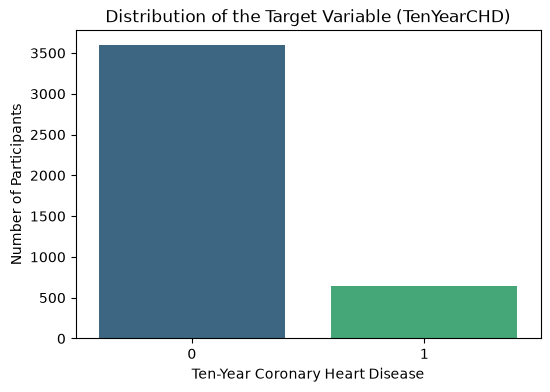

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="TenYearCHD",
    hue="TenYearCHD",
    palette="viridis",
    legend=False
)

plt.title("Distribution of the Target Variable (TenYearCHD)")
plt.xlabel("Ten-Year Coronary Heart Disease")
plt.ylabel("Number of Participants")

plt.show()

The distribution of the target variable indicates that 3,596 participants (84.81%) did not develop coronary heart disease (CHD) within ten years, whereas 644 participants (15.19%) developed CHD during the same period. This distribution reveals a moderate class imbalance, with the majority class substantially larger than the minority class. Such imbalance is common in clinical prediction datasets and will be considered during the model development and evaluation stages to ensure reliable and unbiased predictive performance.

### **Distribution of Continuous Variables**

The distributions of the continuous variables are examined to understand their underlying patterns, identify potential skewness, and detect the presence of outliers. Histograms with kernel density estimates (KDE) are used to visualize the frequency distribution of each variable, providing insights into their suitability for subsequent statistical analysis and machine learning.

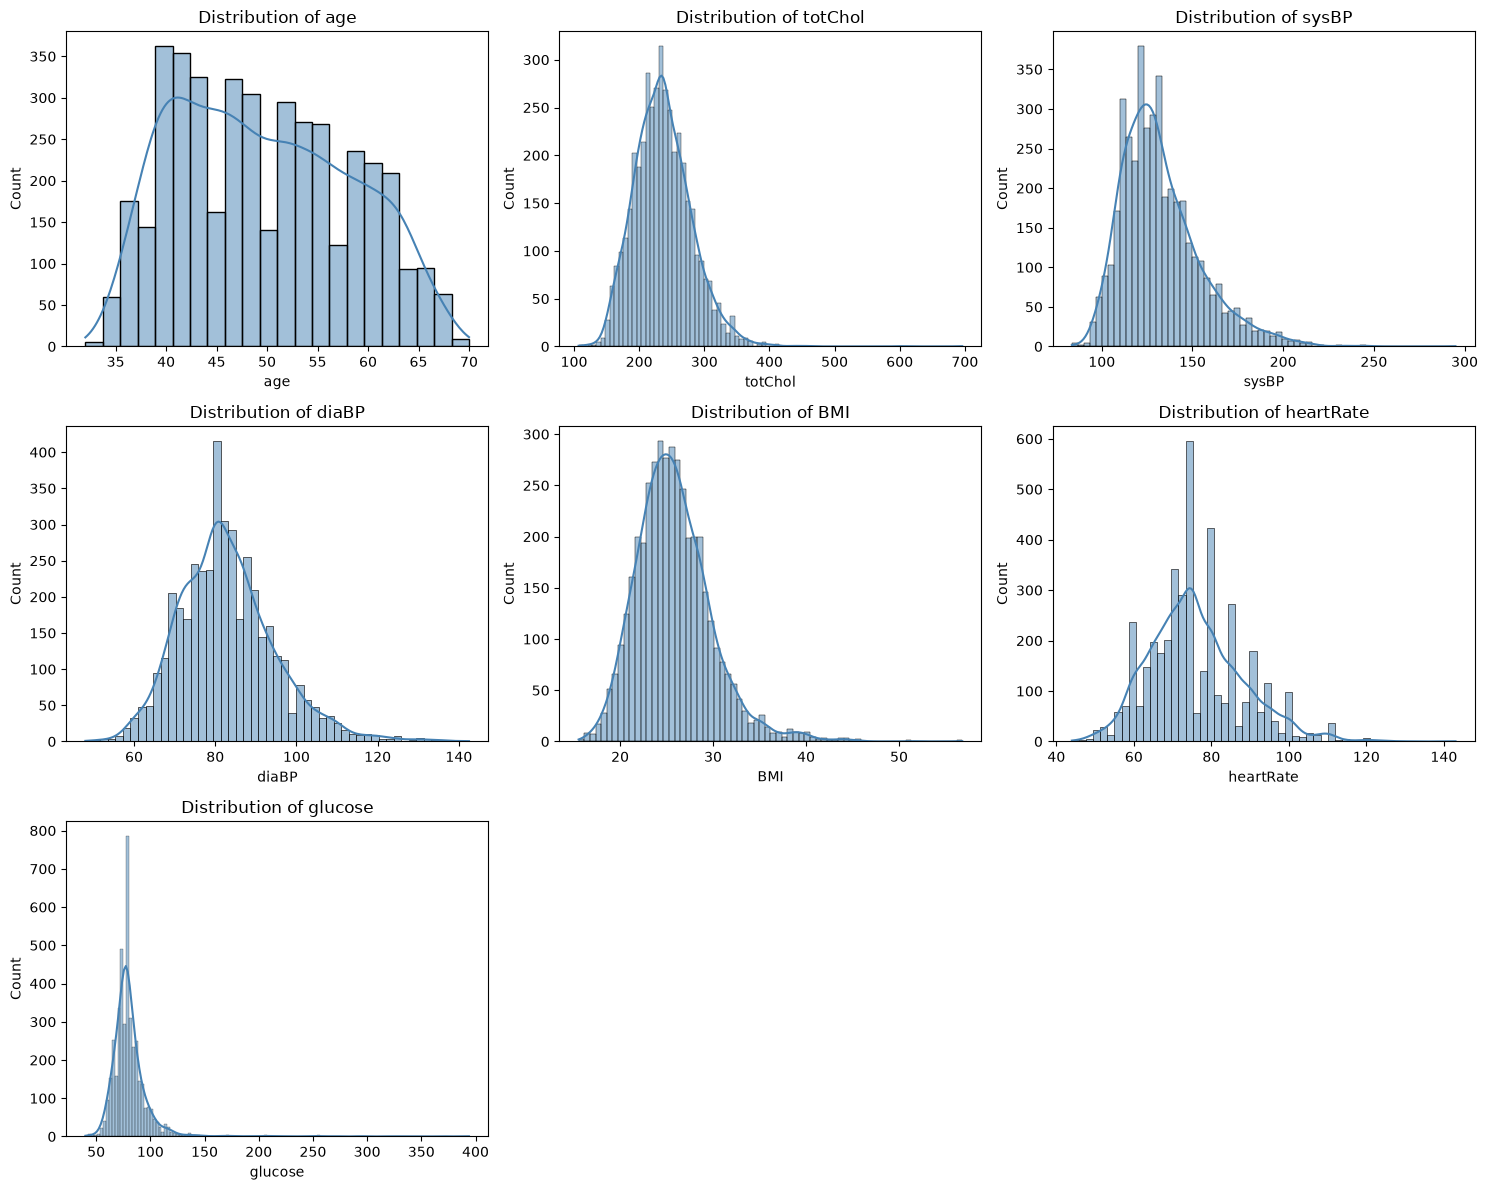

In [21]:
# Select continuous variables
continuous_features = [
    "age",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

# Plot the distribution of each continuous variable
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(f"Distribution of {feature}")

# Remove unused subplot axes
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The distributions of the continuous variables reveal varying distributional patterns across the dataset. The `age` variable appears relatively well distributed across the study population, while `diaBP` (diastolic blood pressure) and `heartRate` exhibit approximately bell-shaped distributions with slight positive skewness. In contrast, `totChol` (total cholesterol), `sysBP` (systolic blood pressure), `BMI` (body mass index), and `glucose` demonstrate noticeable positive skewness, with a small number of high-value observations extending the right tails of their distributions.

These distributional patterns suggest the presence of potential outliers in several physiological variables, particularly `totChol`, `sysBP`, `BMI`, and `glucose`. Consequently, a dedicated outlier analysis will be performed in the subsequent section to further examine these observations and assess their potential influence on the machine learning models.

### **Target Variable Analysis: Feature Correlation**

Finally, Pearson correlation coefficients between all independent physiological features and the target variable were calculated and visualized using a correlation matrix heatmap. This analysis was conducted to identify the primary linear risk factors for cardiovascular disease and to check for severe multicollinearity among the independent variables.


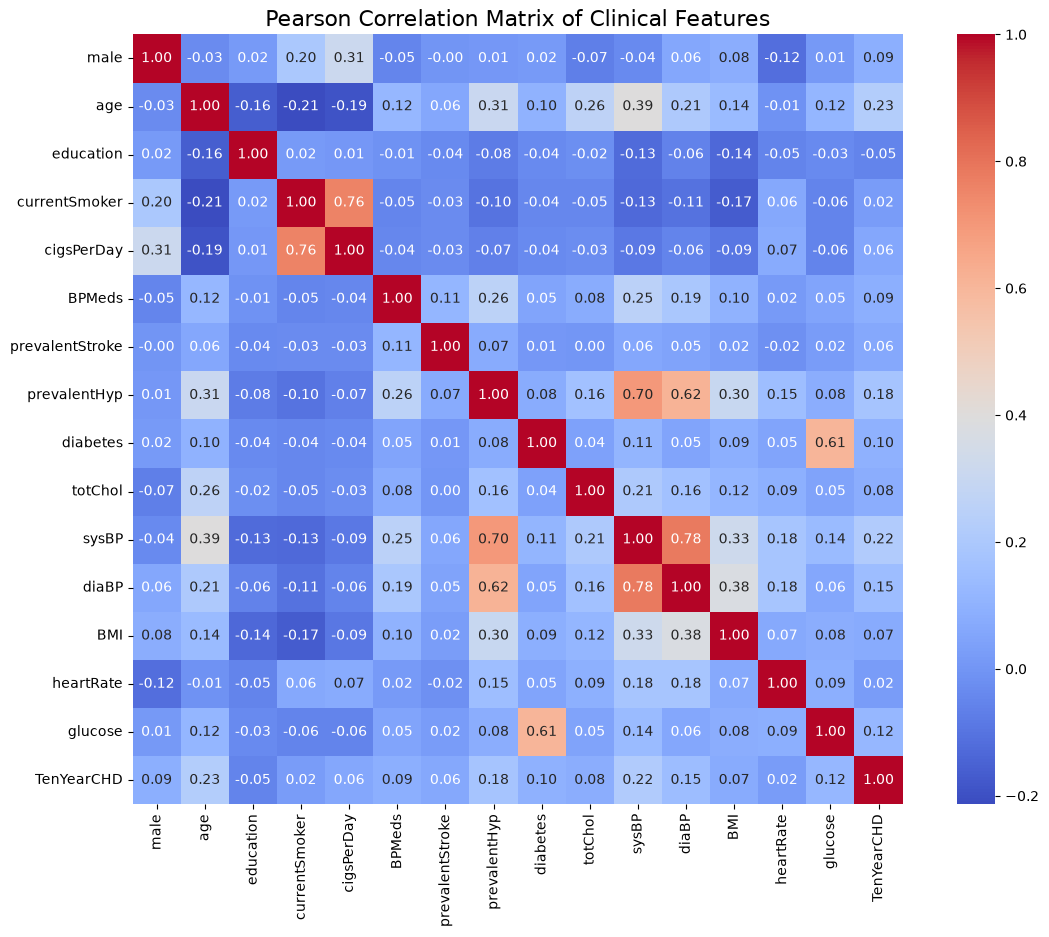

In [23]:
# Compute the Pearson correlation matrix for all numerical variables
corr_matrix = df.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(14, 10))

# Draw the heatmap using seaborn (which looks much better than standard matplotlib!)
sns.heatmap(
    corr_matrix, 
    annot=True,          # Shows the actual correlation numbers
    fmt=".2f",           # Rounds the numbers to 2 decimal places
    cmap="coolwarm",     # Blue for negative correlation, Red for positive
    cbar=True,           # Shows the color bar on the right
    square=True          # Makes the grid squares perfectly proportional
)

plt.title("Pearson Correlation Matrix of Clinical Features", fontsize=16)
plt.show()


The Pearson correlation matrix provides an overview of the linear relationships among the predictor variables and the target variable, `TenYearCHD`. Overall, most features exhibit weak to moderate correlations with the target, indicating that no single variable is solely responsible for predicting the occurrence of coronary heart disease.

Among the predictor variables, `age` (`r = 0.23`) and `sysBP` (`r = 0.22`) demonstrate the strongest positive correlations with `TenYearCHD`, followed by `prevalentHyp` (`r = 0.18`), `diaBP` (`r = 0.15`), and `glucose` (`r = 0.12`). These findings suggest that increasing age, elevated blood pressure, hypertension, and higher glucose levels are associated with a greater likelihood of developing coronary heart disease within ten years. Conversely, variables such as `education`, `currentSmoker`, `heartRate`, and `cigsPerDay` exhibit very weak correlations with the target variable.

The correlation matrix also reveals several moderate to strong relationships among the predictor variables. Notably, `sysBP` and `diaBP` exhibit a strong positive correlation (`r = 0.78`), while `currentSmoker` and `cigsPerDay` (`r = 0.76`), `prevalentHyp` and `sysBP` (`r = 0.70`), `prevalentHyp` and `diaBP` (`r = 0.62`), and `diabetes` and `glucose` (`r = 0.61`) also demonstrate relatively strong associations. These relationships are clinically expected, as the variables measure related physiological characteristics or health conditions.

Overall, although several predictor variables exhibit moderate to strong intercorrelations, no evidence of severe multicollinearity is observed. The correlation analysis therefore indicates that the variables are suitable for subsequent feature engineering and machine learning model development.


### **Outlier Analysis**

Outlier analysis was conducted to identify extreme observations within the continuous features of the dataset. Boxplots were used to visualize the spread of each variable and detect potential outliers based on the interquartile range (IQR). This analysis helps assess the variability of the data and determine whether extreme values require further consideration before model development.

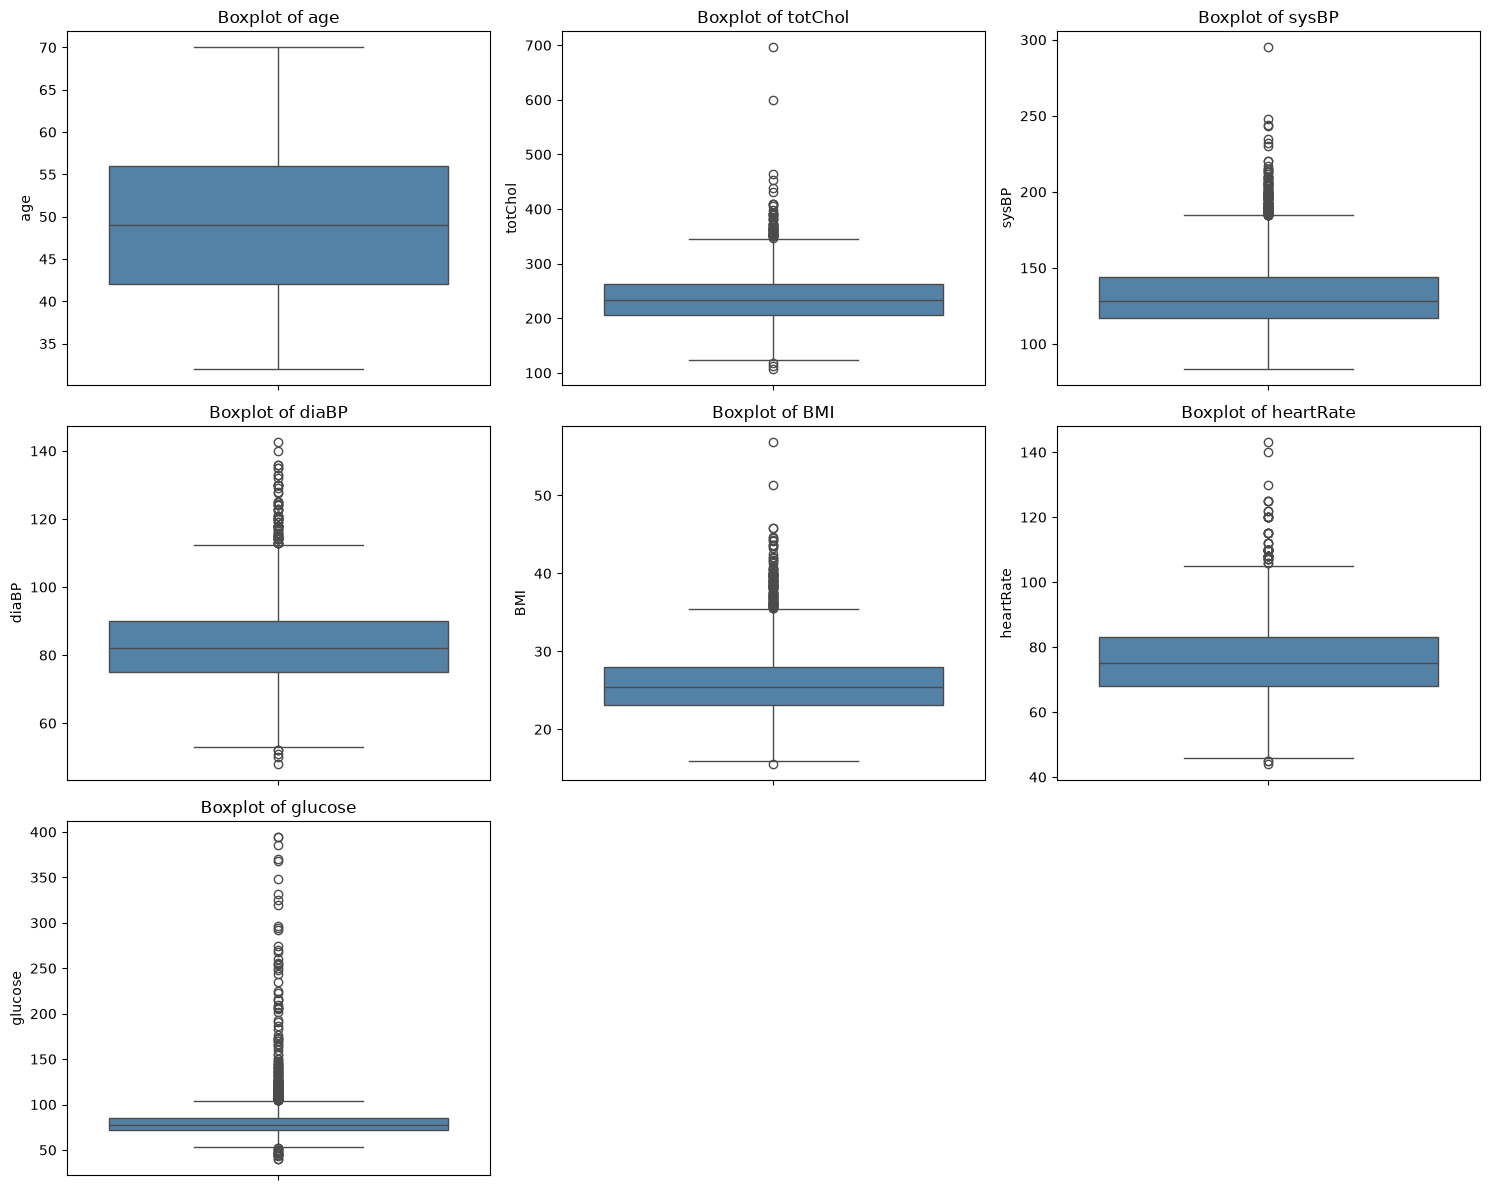

In [24]:
# Select continuous features
continuous_features = [
    "age",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

# Create boxplots for continuous features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.boxplot(
        y=df[feature],
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(f"Boxplot of {feature}")

# Remove unused axes
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The boxplots provide a visual assessment of the distribution and potential outliers within the continuous features of the dataset. The `age` variable does not exhibit any notable outliers, indicating a relatively consistent distribution across the study population. In contrast, `totChol`, `sysBP`, `diaBP`, `BMI`, `heartRate`, and `glucose` display varying numbers of observations beyond the interquartile range (IQR), with `glucose`, `sysBP`, and `totChol` exhibiting the largest concentration of upper outliers.

The presence of these extreme observations is consistent with the positively skewed distributions observed in the previous section and is expected in clinical datasets, where a subset of individuals may present with unusually high physiological measurements. Since these values may represent genuine clinical conditions rather than data entry errors, they will be retained for subsequent analysis and machine learning model development.

**Next Phase:** Logistic Regression